In [ ]:
!pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 33.8 MB/s eta 0:00:00


In [ ]:
!pip install minisom

  Preparing metadata (setup.py) ... done
  Created wheel for minisom: filename=MiniSom-2.3.6-py3-none-any.whl size=13083 sha256=029fb5da995330bf7b00df719e55cd6e43041116f916928b5a49230459471c05
  Stored in directory: /root/.cache/pip/wheels/84/35/b8/48b06bd8cae7187916c28a29c6daa9e0ff610647a2dfa62b97
Successfully built minisom


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

In [ ]:
df = pd.read_excel('scoring.xlsx')

df


,Customer_ID,Month,Age,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,...,Num_Credit_Inquiries,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score
0,CUS_0xd40,3,23.0,12,19114.12,1824.843333,3,4,3,4.0,...,4.0,3,809.98,26.822620,1,49.574949,80.415295,3,312.494089,0
1,CUS_0xd40,2,23.0,12,19114.12,NaN,3,4,3,4.0,...,4.0,1,809.98,31.944960,1,49.574949,118.280222,4,284.629162,0
2,CUS_0xd40,6,-500.0,12,19114.12,NaN,3,4,3,4.0,...,4.0,1,809.98,28.609352,1,49.574949,81.699521,5,331.209863,0
3,CUS_0xd40,0,23.0,12,19114.12,NaN,3,4,3,4.0,...,4.0,1,809.98,31.377862,1,49.574949,199.458074,6,223.451310,0
4,CUS_0xd40,7,23.0,12,19114.12,1824.843333,3,4,3,4.0,...,4.0,1,809.98,24.797347,1,49.574949,41.420153,2,341.489231,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,CUS_0x942c,0,25.0,9,39628.99,3359.415833,4,6,7,2.0,...,3.0,3,502.38,34.663572,1,35.104023,60.971333,1,479.866228,1
99996,CUS_0x942c,7,25.0,9,39628.99,3359.415833,4,6,7,2.0,...,3.0,3,502.38,40.565631,1,35.104023,54.185950,2,496.651610,1
99997,CUS_0x942c,5,25.0,9,39628.99,3359.415833,4,6,5729,2.0,...,3.0,1,502.38,41.255522,1,35.104023,24.028477,1,516.809083,1
99998,CUS_0x942c,4,25.0,9,39628.99,3359.415833,4,6,7,2.0,...,3.0,1,502.38,33.638208,1,35.104023,251.672582,4,319.164979,0


In [ ]:
df.describe()

,Month,Age,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Delay_from_due_date,...,Num_Credit_Inquiries,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score
count,100000.000000,95061.000000,100000.000000,1.000000e+05,84998.000000,100000.000000,100000.00000,100000.000000,95215.000000,100000.000000,...,98035.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,95521.000000,100000.000000,9.880000e+04,100000.000000
mean,3.500000,110.934505,7.523380,1.764157e+05,4194.170850,17.091280,22.47443,72.466040,2.780339,21.068780,...,27.754251,1.578800,1426.220376,32.285173,1.403190,1403.118217,637.412998,3.469040,3.036437e+22,0.289980
std,2.291299,689.407864,4.640296,1.429618e+06,3183.686167,117.404834,129.05741,466.422621,62.500940,14.860104,...,193.177339,1.013647,1155.129026,5.116875,0.693378,8306.041270,2043.319327,2.035471,3.181295e+24,0.453755
min,0.000000,-500.000000,0.000000,7.005930e+03,303.645417,-1.000000,0.00000,1.000000,-100.000000,-5.000000,...,0.000000,0.000000,0.230000,20.000000,0.000000,0.000000,0.000000,0.000000,7.759665e-03,0.000000
25%,1.750000,24.000000,4.000000,1.945750e+04,1625.568229,3.000000,4.00000,8.000000,1.000000,10.000000,...,3.000000,1.000000,566.072500,28.052567,1.000000,30.306660,74.534002,2.000000,2.701145e+02,0.000000
50%,3.500000,33.000000,7.000000,3.757861e+04,3093.745000,6.000000,5.00000,13.000000,3.000000,18.000000,...,6.000000,2.000000,1166.155000,32.305784,2.000000,69.249473,135.925682,3.000000,3.367423e+02,0.000000
75%,5.250000,42.000000,12.000000,7.279092e+04,5957.448333,7.000000,7.00000,20.000000,5.000000,28.000000,...,9.000000,2.000000,1945.962500,36.496663,2.000000,161.224249,265.731733,6.000000,4.703321e+02,1.000000
max,7.000000,8698.000000,15.000000,2.419806e+07,15204.633333,1798.000000,1499.00000,5797.000000,1496.000000,67.000000,...,2597.000000,3.000000,4998.070000,50.000000,2.000000,82331.000000,10000.000000,6.000000,3.333333e+26,1.000000


In [ ]:
df.isnull().sum()

,0
Customer_ID,0
Month,0
Age,4939
Occupation,0
Annual_Income,0
Monthly_Inhand_Salary,15002
Num_Bank_Accounts,0
Num_Credit_Card,0
Interest_Rate,0
Num_of_Loan,4785


In [ ]:
numeric_cols = df.select_dtypes(include=['number']).columns
for col in numeric_cols:
    df[col] = df[col].fillna(df[col].median())

In [ ]:
df.isnull().sum()

,0
Customer_ID,0
Month,0
Age,0
Occupation,0
Annual_Income,0
Monthly_Inhand_Salary,0
Num_Bank_Accounts,0
Num_Credit_Card,0
Interest_Rate,0
Num_of_Loan,0


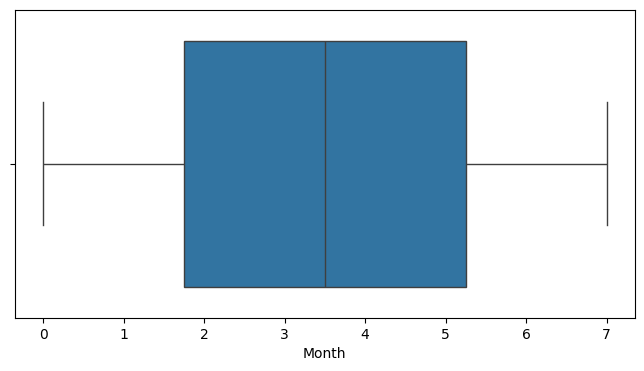

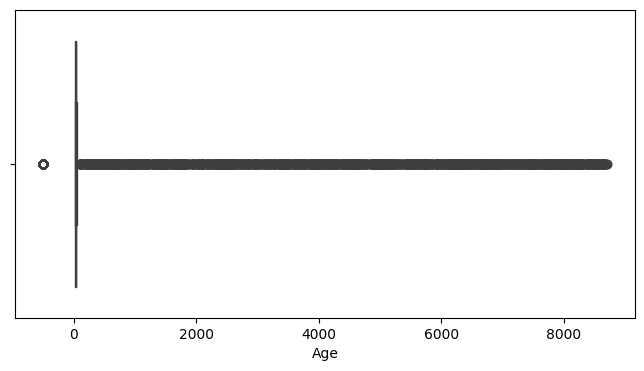

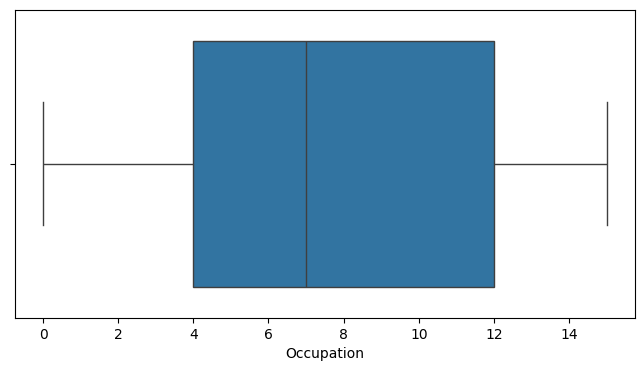

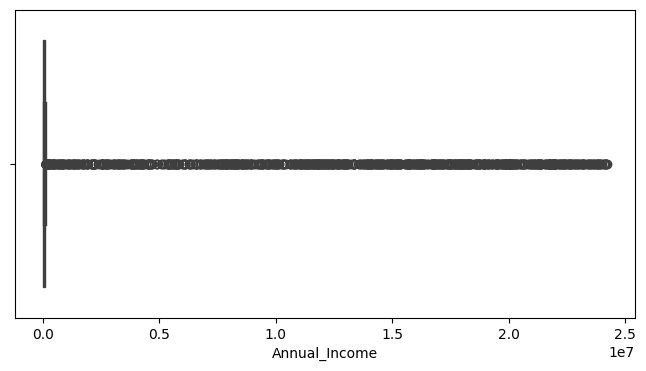

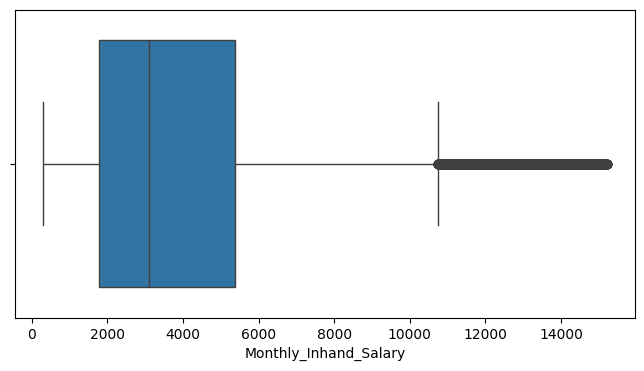

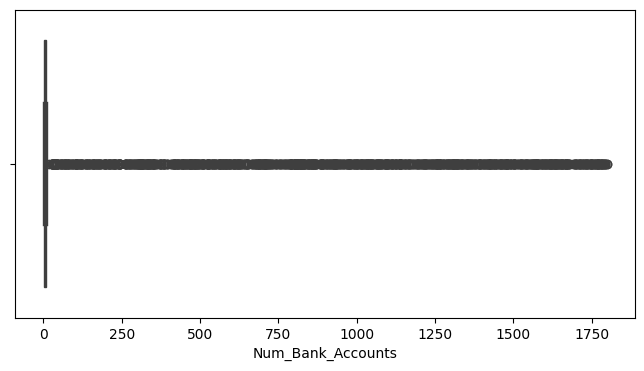

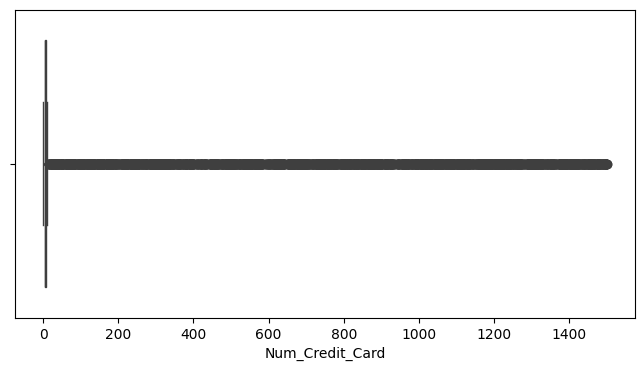

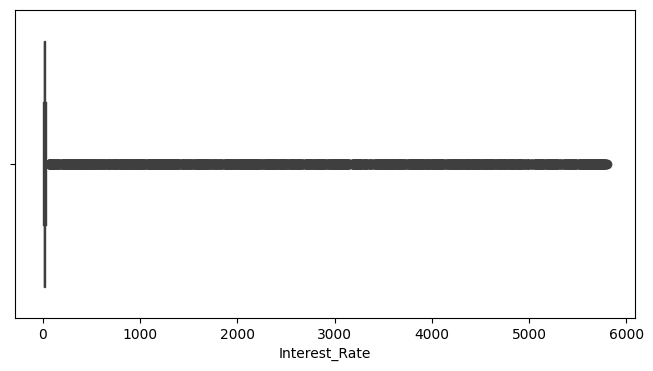

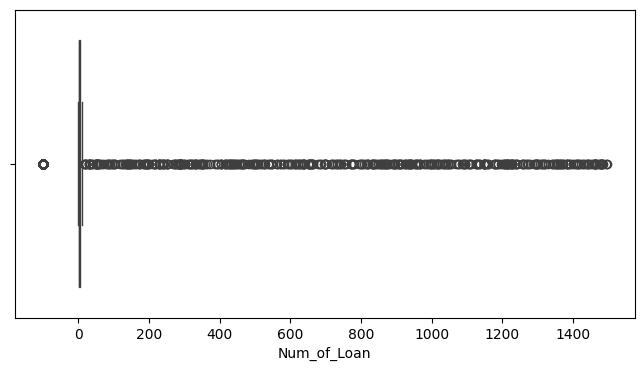

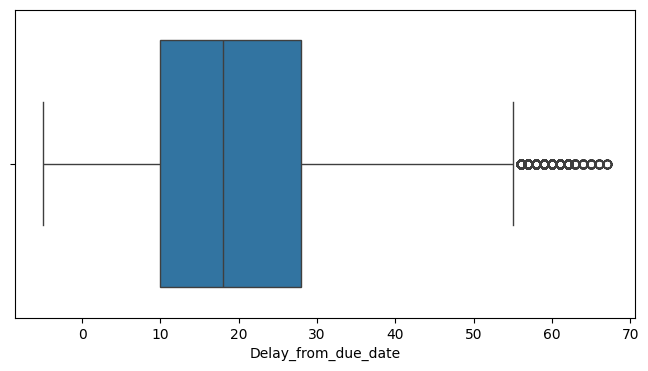

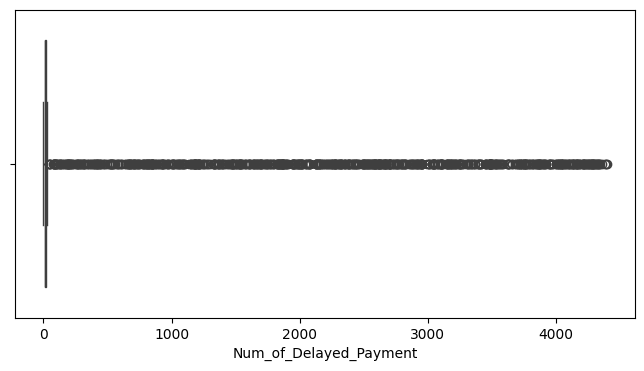

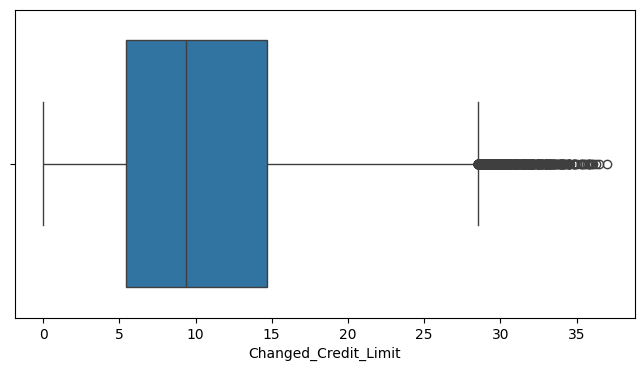

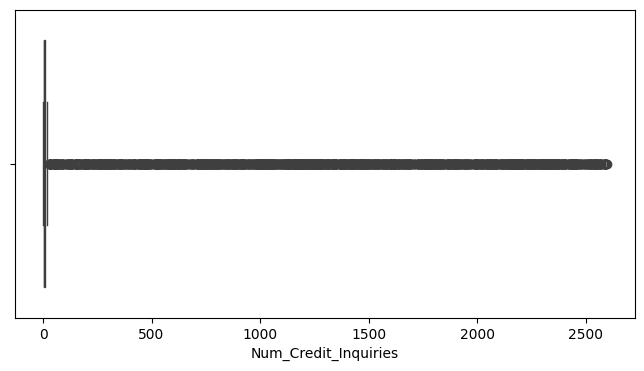

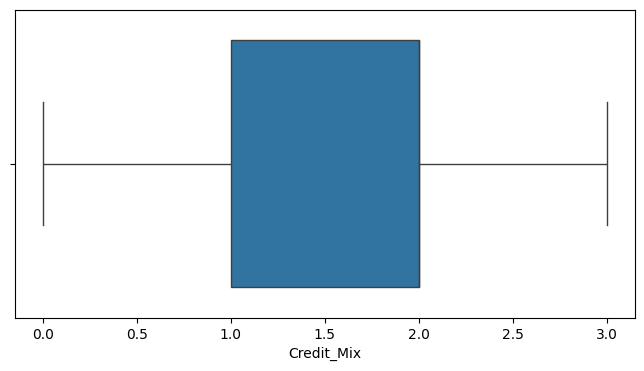

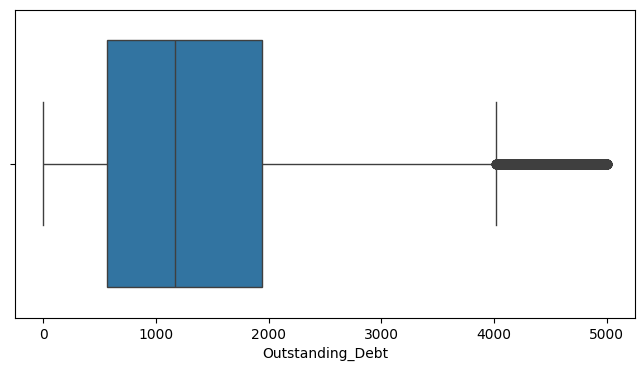

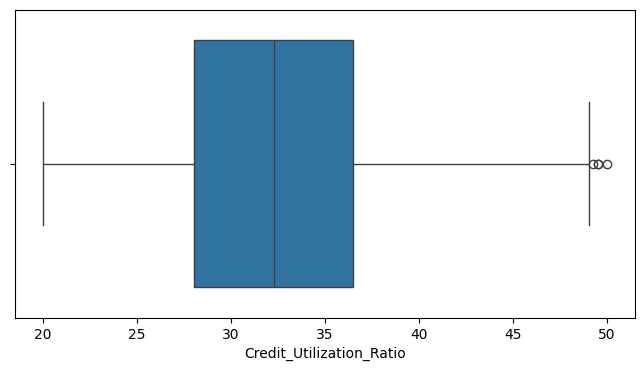

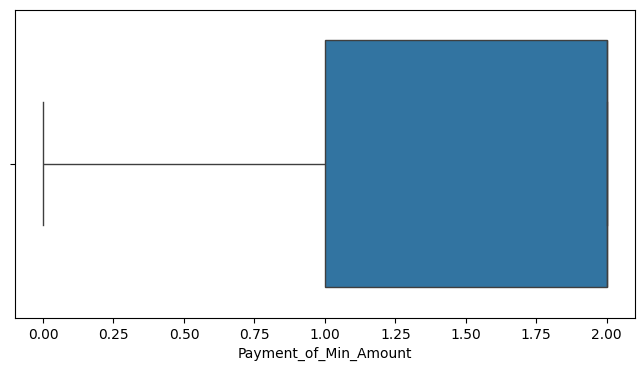

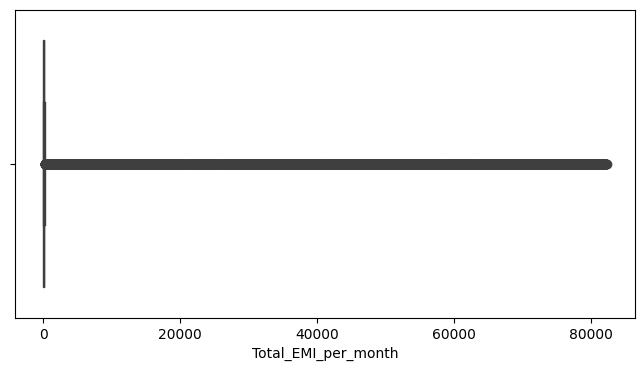

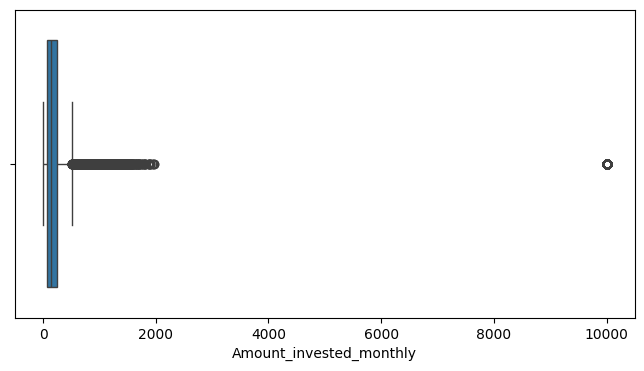

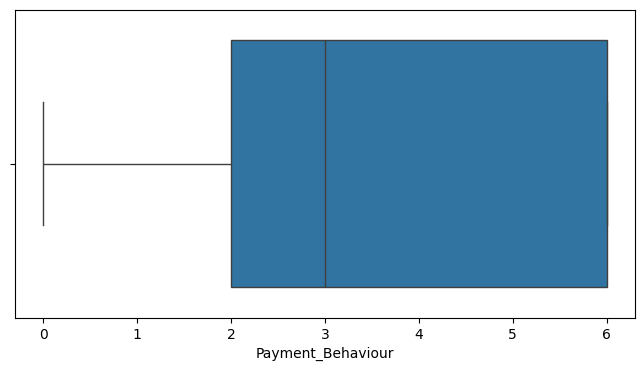

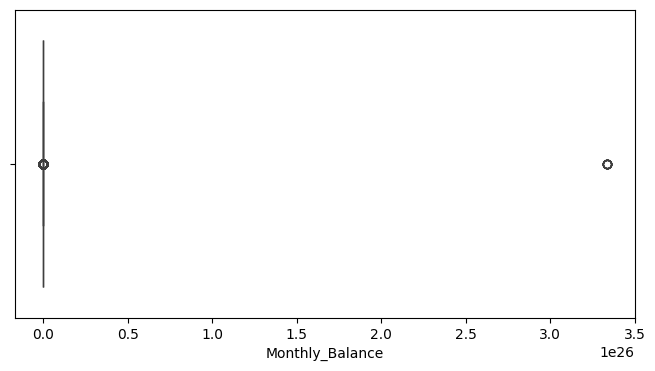

In [ ]:
for i in df.columns:
    if i not in ['Customer_ID', 'Credit_Score']:
        if df[i].dtypes != object:
            plt.figure(figsize=(8, 4))
            sns.boxplot(x=df[i])
            plt.show()

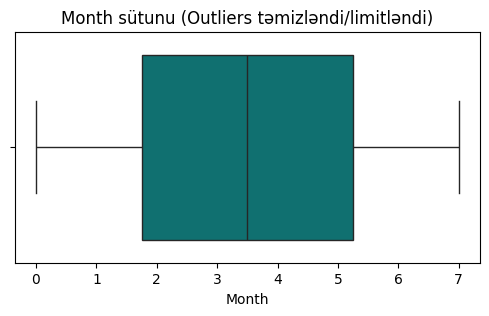

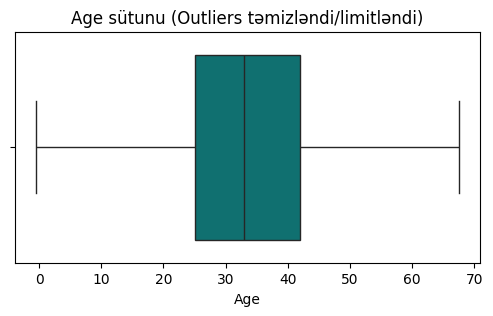

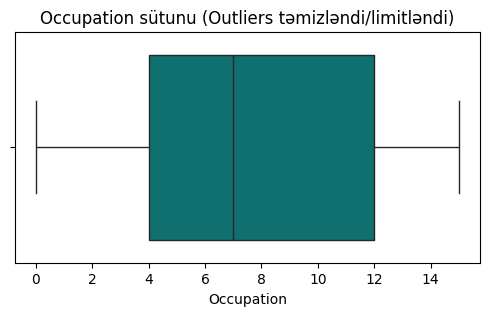

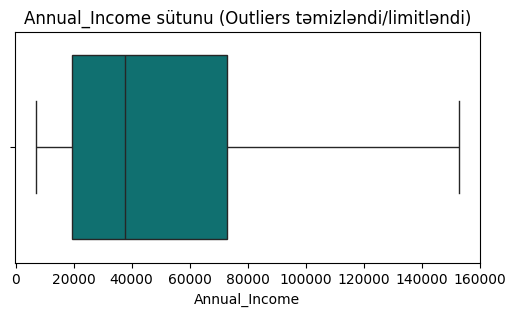

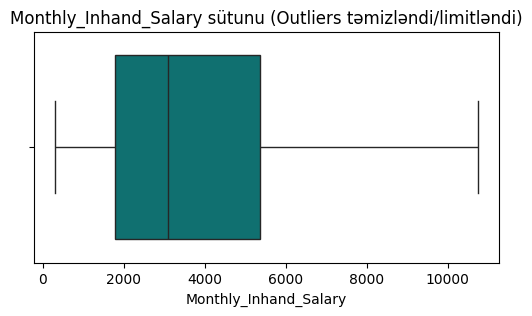

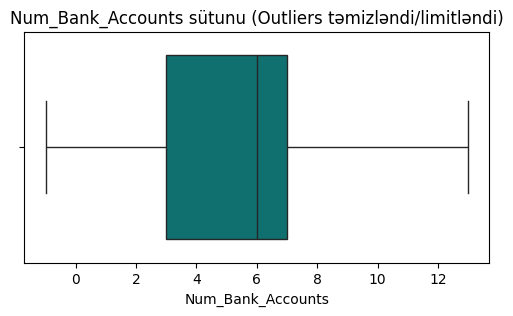

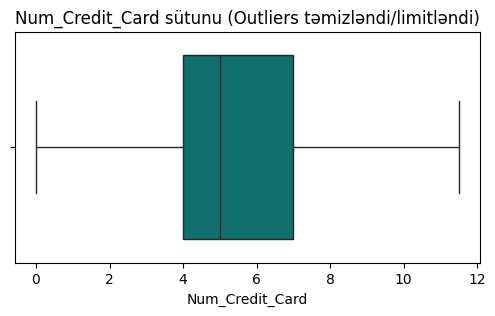

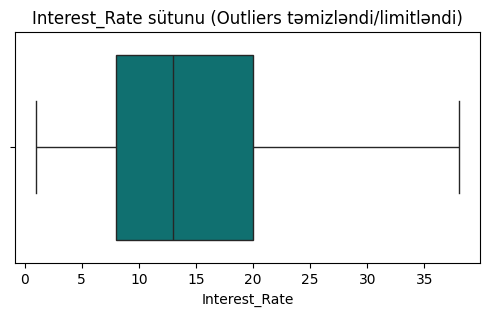

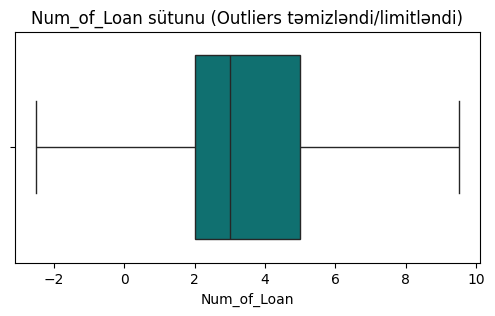

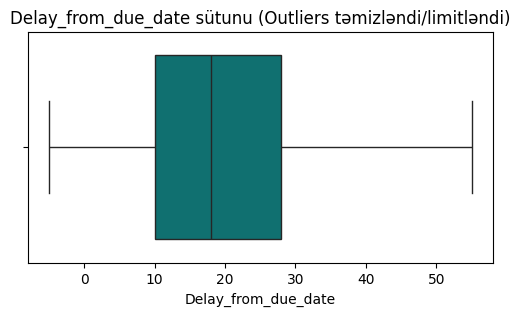

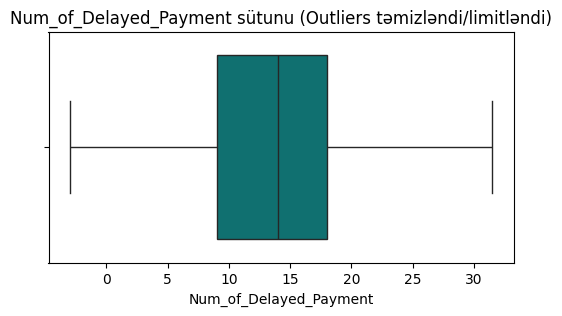

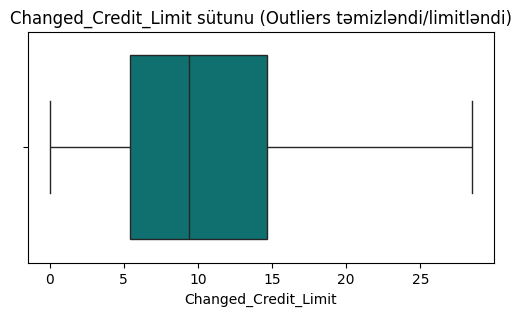

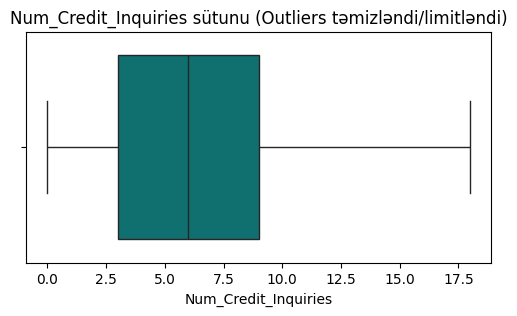

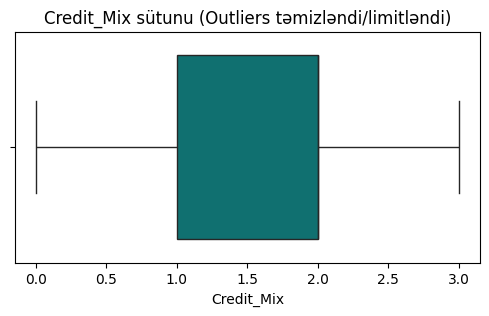

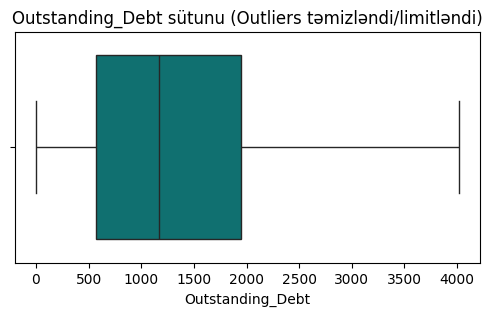

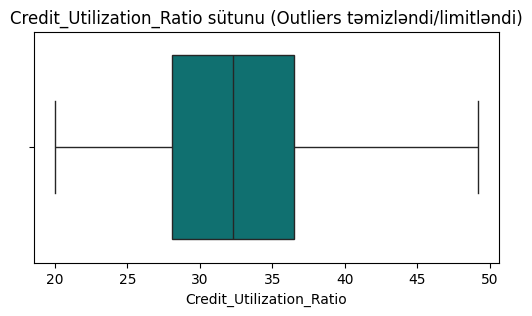

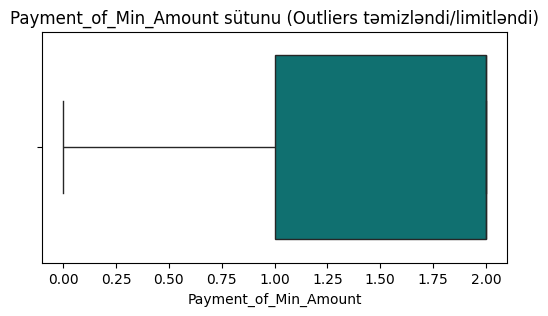

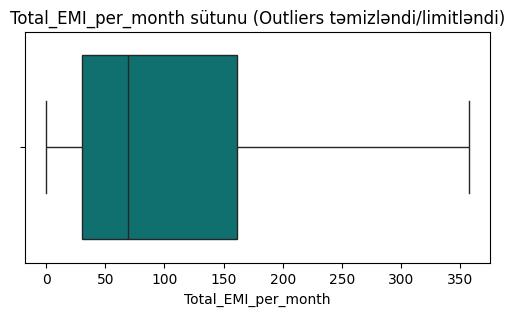

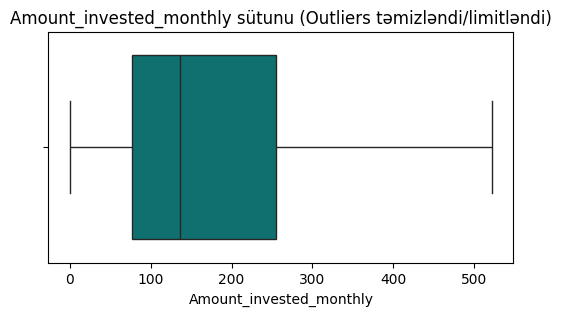

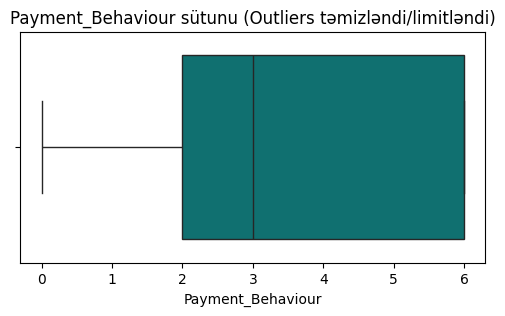

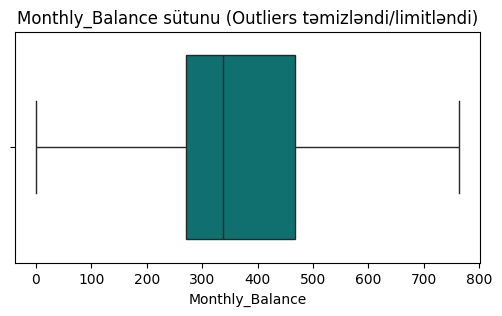

In [ ]:
for i in df.columns:
    if df[i].dtype != 'object' and df[i].nunique() > 2 and i not in ['Customer_ID', 'Credit_Score']:

        Q1 = df[i].quantile(0.25)
        Q3 = df[i].quantile(0.75)
        IQR = Q3 - Q1

        Lower_Limit = Q1 - 1.5 * IQR
        Upper_Limit = Q3 + 1.5 * IQR

        df[i] = np.where(df[i] > Upper_Limit, Upper_Limit, df[i])
        df[i] = np.where(df[i] < Lower_Limit, Lower_Limit, df[i])

        plt.figure(figsize=(6, 3))
        sns.boxplot(x=df[i], color='teal')
        plt.title(f'{i} sütunu (Outliers təmizləndi/limitləndi)')
        plt.show()

In [ ]:
inputs = df.drop(['Customer_ID', 'Credit_Score'], axis=1)
target = df['Credit_Score']

In [ ]:
inputs

,Month,Age,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Delay_from_due_date,...,Changed_Credit_Limit,Num_Credit_Inquiries,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance
0,3.0,23.0,12.0,19114.12,1824.843333,3.0,4.0,3.0,4.0,3.0,...,11.27,4.0,3.0,809.98,26.822620,1.0,49.574949,80.415295,3.0,312.494089
1,2.0,23.0,12.0,19114.12,3093.745000,3.0,4.0,3.0,4.0,-1.0,...,11.27,4.0,1.0,809.98,31.944960,1.0,49.574949,118.280222,4.0,284.629162
2,6.0,-0.5,12.0,19114.12,3093.745000,3.0,4.0,3.0,4.0,3.0,...,9.40,4.0,1.0,809.98,28.609352,1.0,49.574949,81.699521,5.0,331.209863
3,0.0,23.0,12.0,19114.12,3093.745000,3.0,4.0,3.0,4.0,5.0,...,6.27,4.0,1.0,809.98,31.377862,1.0,49.574949,199.458074,6.0,223.451310
4,7.0,23.0,12.0,19114.12,1824.843333,3.0,4.0,3.0,4.0,6.0,...,11.27,4.0,1.0,809.98,24.797347,1.0,49.574949,41.420153,2.0,341.489231
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,0.0,25.0,9.0,39628.99,3359.415833,4.0,6.0,7.0,2.0,23.0,...,11.50,3.0,3.0,502.38,34.663572,1.0,35.104023,60.971333,1.0,479.866228
99996,7.0,25.0,9.0,39628.99,3359.415833,4.0,6.0,7.0,2.0,18.0,...,11.50,3.0,3.0,502.38,40.565631,1.0,35.104023,54.185950,2.0,496.651610
99997,5.0,25.0,9.0,39628.99,3359.415833,4.0,6.0,38.0,2.0,27.0,...,11.50,3.0,1.0,502.38,41.255522,1.0,35.104023,24.028477,1.0,516.809083
99998,4.0,25.0,9.0,39628.99,3359.415833,4.0,6.0,7.0,2.0,20.0,...,11.50,3.0,1.0,502.38,33.638208,1.0,35.104023,251.672582,4.0,319.164979


In [ ]:
target

,Credit_Score
0,0
1,0
2,0
3,0
4,0
...,...
99995,1
99996,1
99997,1
99998,0


In [ ]:
from sklearn.preprocessing import MinMaxScaler

sc = MinMaxScaler(feature_range = (0, 1))
inputs_scaled = sc.fit_transform(inputs)

In [ ]:
inputs_scaled

array([[0.42857143, 0.34558824, 0.8       , ..., 0.15403145, 0.5       ,
        0.40957746],
       [0.28571429, 0.34558824, 0.8       , ..., 0.22655981, 0.66666667,
        0.37305476],
       [0.85714286, 0.        , 0.8       , ..., 0.15649132, 0.83333333,
        0.43410832],
       ...,
       [0.71428571, 0.375     , 0.6       , ..., 0.04602534, 0.16666667,
        0.67737419],
       [0.57142857, 0.375     , 0.6       , ..., 0.48206616, 0.66666667,
        0.41832103],
       [0.14285714, 0.375     , 0.6       , ..., 0.32019397, 0.        ,
        0.51598   ]])

In [ ]:
import optuna
from sklearn.metrics import silhouette_score
from minisom import MiniSom

def objective(trial):

    x = trial.suggest_int("x", 5, 20)
    y = trial.suggest_int("y", 5, 20)
    sigma = trial.suggest_float("sigma", 0.1, 2.0, log=True)
    learning_rate = trial.suggest_float("learning_rate", 0.01, 1.0, log=True)
    num_iteration = trial.suggest_int("num_iteration", 50, 500)

    # Initialize SOM
    som = MiniSom(x=x, y=y, input_len=inputs_scaled.shape[1], sigma=sigma, learning_rate=learning_rate)
    som.random_weights_init(inputs_scaled)
    som.train_random(data=inputs_scaled, num_iteration=num_iteration)

    # Assign each input to the closest SOM neuron
    labels = np.array([som.winner(x) for x in inputs_scaled])
    print(labels)
    # Flatten the neuron indices for silhouette_score
    flattened_labels = [i[0] * y + i[1] for i in labels]

    # Evaluate clustering using silhouette score (higher is better)
    try:
        score = silhouette_score(inputs_scaled, flattened_labels)
    except ValueError:
        score = -1  # Assign a negative score if clustering fails

    return score

# Run the optimization
study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=20)

# Display the best parameters
print("Best parameters:", study.best_params)
print("Best silhouette score:", study.best_value)


[I 2026-05-11 11:12:16,929] A new study created in memory with name: no-name-996de7c0-822e-43eb-9dc1-8c3580f434b5


[[ 5 12]
 [ 0 10]
 [ 2 10]
 ...
 [ 3  9]
 [ 3  9]
 [ 0 10]]


[I 2026-05-11 11:14:10,669] Trial 0 finished with value: 0.015950591820837797 and parameters: {'x': 17, 'y': 15, 'sigma': 1.6175141327393106, 'learning_rate': 0.04796376272367159, 'num_iteration': 259}. Best is trial 0 with value: 0.015950591820837797.


[[17  4]
 [ 1  5]
 [ 6 11]
 ...
 [ 4  5]
 [14  5]
 [ 0  2]]


[I 2026-05-11 11:16:03,677] Trial 1 finished with value: 0.01201169813871266 and parameters: {'x': 20, 'y': 15, 'sigma': 0.2906931784270473, 'learning_rate': 0.06268402384315933, 'num_iteration': 63}. Best is trial 0 with value: 0.015950591820837797.


...

[[1 5]
 [1 5]
 [2 6]
 ...
 [4 6]
 [2 6]
 [1 5]]


[I 2026-05-11 11:47:33,064] Trial 18 finished with value: 0.02738869353968335 and parameters: {'x': 7, 'y': 7, 'sigma': 0.9370812910438027, 'learning_rate': 0.010254832959100454, 'num_iteration': 187}. Best is trial 10 with value: 0.03900293861193532.


[[2 3]
 [2 3]
 [2 4]
 ...
 [1 4]
 [1 0]
 [0 0]]


[I 2026-05-11 11:49:23,091] Trial 19 finished with value: 0.04066152029095689 and parameters: {'x': 6, 'y': 5, 'sigma': 1.2249122251082276, 'learning_rate': 0.029960556221537548, 'num_iteration': 443}. Best is trial 19 with value: 0.04066152029095689.


Best parameters: {'x': 6, 'y': 5, 'sigma': 1.2249122251082276, 'learning_rate': 0.029960556221537548, 'num_iteration': 443}
Best silhouette score: 0.04066152029095689


In [ ]:
best_params = study.best_params
best_params

{'x': 6,
 'y': 5,
 'sigma': 1.2249122251082276,
 'learning_rate': 0.029960556221537548,
 'num_iteration': 443}

In [ ]:
# Initialize SOM with the best parameters
som_opt = MiniSom(x=best_params['x'], y=best_params['y'], input_len=21,
              sigma=best_params['sigma'], learning_rate=best_params['learning_rate'])

som_opt.random_weights_init(inputs_scaled)

som_opt.train_random(data=inputs_scaled, num_iteration=best_params['num_iteration'])


In [ ]:
y = target

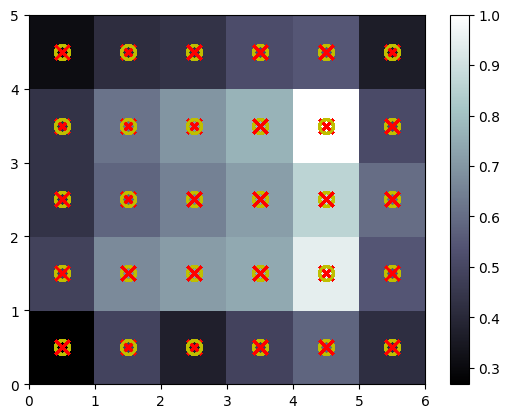

In [ ]:
from pylab import bone, pcolor, colorbar, plot, show
bone()
pcolor(som_opt.distance_map().T)  # Display the distance map
colorbar()
markers = ['x', 'o']  # x for rejected and o for accepted
colors = ['r', 'y']  # r for red and y for yellow

for i, x in enumerate(inputs_scaled):
    w = som_opt.winner(x)
    plot(w[0] + 0.5,
         w[1] + 0.5,
         markers[y[i]],
         markeredgecolor=colors[y[i]],
         markerfacecolor='None',
         markersize=10,
         markeredgewidth=2)

show()

In [ ]:
distance_map = som_opt.distance_map()

threshold = 0.9

white_nodes = [(i, j) for i in range(distance_map.shape[0]) for j in range(distance_map.shape[1]) if distance_map[i, j] >= threshold]

print("Positions of Nodes (Distance >= 0.9):")
for node in white_nodes:
    print(f"Node {node} - Distance: {distance_map[node[0], node[1]]:.2f}")


Positions of Nodes (Distance >= 0.9):
Node (4, 1) - Distance: 0.94
Node (4, 3) - Distance: 1.00


In [ ]:
mappings = som_opt.win_map(inputs_scaled)

frauds = []

for node in white_nodes:
    if node in mappings:
        fraud_data = mappings[node]
        frauds.append(fraud_data)

frauds = np.concatenate(frauds, axis=0)

frauds = sc.inverse_transform(frauds)

frauds

array([[ 2.00000000e+00, -5.00000000e-01,  5.00000000e+00, ...,
         3.00323232e+02,  6.00000000e+00,  1.29933631e+02],
       [ 0.00000000e+00,  4.60000000e+01,  1.30000000e+01, ...,
         2.80218254e+02,  6.00000000e+00,  1.96582686e+02],
       [ 3.00000000e+00,  1.50000000e+01,  5.00000000e+00, ...,
         3.48799489e+02,  6.00000000e+00,  6.32469762e+01],
       ...,
       [ 7.00000000e+00,  4.00000000e+01,  1.20000000e+01, ...,
         5.22070624e+02,  6.00000000e+00,  3.36742315e+02],
       [ 5.00000000e+00,  4.00000000e+01,  1.20000000e+01, ...,
         3.14580409e+02,  5.00000000e+00,  2.58156482e+02],
       [ 4.00000000e+00,  3.30000000e+01,  1.50000000e+01, ...,
         5.22070624e+02,  5.00000000e+00,  3.36742315e+02]])

In [ ]:
frauds_df = pd.DataFrame(frauds, columns=inputs.columns)

frauds_df

,Month,Age,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Delay_from_due_date,...,Changed_Credit_Limit,Num_Credit_Inquiries,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance
0,2.0,-0.5,5.0,25546.26,3093.745000,8.0,7.0,14.0,5.0,16.0,...,7.83,6.0,2.0,758.4400,29.711376,2.0,101.328637,300.323232,6.0,129.933631
1,0.0,46.0,13.0,32284.62,2898.385000,6.0,7.0,17.0,6.0,11.0,...,9.22,8.0,2.0,1283.3700,38.394558,2.0,103.037560,280.218254,6.0,196.582686
2,3.0,15.0,5.0,55829.79,4369.482500,10.0,10.0,18.0,3.0,30.0,...,27.99,11.0,3.0,3422.4900,27.070543,2.0,314.901785,348.799489,6.0,63.246976
3,2.0,43.0,7.0,81842.28,6810.190000,10.0,9.0,25.0,9.0,20.0,...,16.25,9.0,3.0,3053.1600,26.050885,2.0,357.600632,152.733766,0.0,204.219436
4,0.0,26.0,8.0,49967.01,4091.917500,7.0,6.0,31.0,6.0,27.0,...,19.87,11.0,2.0,2253.9500,22.841178,2.0,156.003312,373.168516,5.0,160.019922
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5423,4.0,25.0,11.0,71025.40,5766.783333,7.0,6.0,32.0,-2.5,27.0,...,17.12,10.0,2.0,2542.4200,27.648591,2.0,195.207484,191.555898,0.0,449.914951
5424,0.0,40.0,12.0,81093.16,7017.763333,10.0,7.0,17.0,7.0,29.0,...,15.72,12.0,0.0,4015.7975,29.600431,0.0,357.600632,152.507075,1.0,380.229816
5425,7.0,40.0,12.0,81093.16,7017.763333,10.0,7.0,17.0,7.0,25.0,...,15.72,6.0,0.0,4015.7975,27.419316,2.0,357.600632,522.070624,6.0,336.742315
5426,5.0,40.0,12.0,81093.16,7017.763333,10.0,7.0,17.0,9.5,29.0,...,15.72,12.0,0.0,4015.7975,35.925627,0.0,357.600632,314.580409,5.0,258.156482


In [ ]:
df

,Customer_ID,Month,Age,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,...,Num_Credit_Inquiries,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score
0,CUS_0xd40,3.0,23.0,12.0,19114.12,1824.843333,3.0,4.0,3.0,4.0,...,4.0,3.0,809.98,26.822620,1.0,49.574949,80.415295,3.0,312.494089,0
1,CUS_0xd40,2.0,23.0,12.0,19114.12,3093.745000,3.0,4.0,3.0,4.0,...,4.0,1.0,809.98,31.944960,1.0,49.574949,118.280222,4.0,284.629162,0
2,CUS_0xd40,6.0,-0.5,12.0,19114.12,3093.745000,3.0,4.0,3.0,4.0,...,4.0,1.0,809.98,28.609352,1.0,49.574949,81.699521,5.0,331.209863,0
3,CUS_0xd40,0.0,23.0,12.0,19114.12,3093.745000,3.0,4.0,3.0,4.0,...,4.0,1.0,809.98,31.377862,1.0,49.574949,199.458074,6.0,223.451310,0
4,CUS_0xd40,7.0,23.0,12.0,19114.12,1824.843333,3.0,4.0,3.0,4.0,...,4.0,1.0,809.98,24.797347,1.0,49.574949,41.420153,2.0,341.489231,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,CUS_0x942c,0.0,25.0,9.0,39628.99,3359.415833,4.0,6.0,7.0,2.0,...,3.0,3.0,502.38,34.663572,1.0,35.104023,60.971333,1.0,479.866228,1
99996,CUS_0x942c,7.0,25.0,9.0,39628.99,3359.415833,4.0,6.0,7.0,2.0,...,3.0,3.0,502.38,40.565631,1.0,35.104023,54.185950,2.0,496.651610,1
99997,CUS_0x942c,5.0,25.0,9.0,39628.99,3359.415833,4.0,6.0,38.0,2.0,...,3.0,1.0,502.38,41.255522,1.0,35.104023,24.028477,1.0,516.809083,1
99998,CUS_0x942c,4.0,25.0,9.0,39628.99,3359.415833,4.0,6.0,7.0,2.0,...,3.0,1.0,502.38,33.638208,1.0,35.104023,251.672582,4.0,319.164979,0


In [ ]:
common_cols = list(set(df.columns) & set(frauds_df.columns))

common_cols

['Annual_Income',
 'Num_Credit_Card',
 'Total_EMI_per_month',
 'Payment_Behaviour',
 'Credit_Utilization_Ratio',
 'Monthly_Inhand_Salary',
 'Interest_Rate',
 'Num_Bank_Accounts',
 'Num_of_Loan',
 'Age',
 'Payment_of_Min_Amount',
 'Month',
 'Monthly_Balance',
 'Num_Credit_Inquiries',
 'Occupation',
 'Num_of_Delayed_Payment',
 'Changed_Credit_Limit',
 'Delay_from_due_date',
 'Outstanding_Debt',
 'Credit_Mix',
 'Amount_invested_monthly']

In [ ]:
df1 = df.merge(frauds_df[common_cols].assign(is_fraud=1), how="left", on=common_cols)

df1

,Customer_ID,Month,Age,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,...,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score,is_fraud
0,CUS_0xd40,3.0,23.0,12.0,19114.12,1824.843333,3.0,4.0,3.0,4.0,...,3.0,809.98,26.822620,1.0,49.574949,80.415295,3.0,312.494089,0,NaN
1,CUS_0xd40,2.0,23.0,12.0,19114.12,3093.745000,3.0,4.0,3.0,4.0,...,1.0,809.98,31.944960,1.0,49.574949,118.280222,4.0,284.629162,0,NaN
2,CUS_0xd40,6.0,-0.5,12.0,19114.12,3093.745000,3.0,4.0,3.0,4.0,...,1.0,809.98,28.609352,1.0,49.574949,81.699521,5.0,331.209863,0,NaN
3,CUS_0xd40,0.0,23.0,12.0,19114.12,3093.745000,3.0,4.0,3.0,4.0,...,1.0,809.98,31.377862,1.0,49.574949,199.458074,6.0,223.451310,0,NaN
4,CUS_0xd40,7.0,23.0,12.0,19114.12,1824.843333,3.0,4.0,3.0,4.0,...,1.0,809.98,24.797347,1.0,49.574949,41.420153,2.0,341.489231,0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,CUS_0x942c,0.0,25.0,9.0,39628.99,3359.415833,4.0,6.0,7.0,2.0,...,3.0,502.38,34.663572,1.0,35.104023,60.971333,1.0,479.866228,1,NaN
99996,CUS_0x942c,7.0,25.0,9.0,39628.99,3359.415833,4.0,6.0,7.0,2.0,...,3.0,502.38,40.565631,1.0,35.104023,54.185950,2.0,496.651610,1,NaN
99997,CUS_0x942c,5.0,25.0,9.0,39628.99,3359.415833,4.0,6.0,38.0,2.0,...,1.0,502.38,41.255522,1.0,35.104023,24.028477,1.0,516.809083,1,NaN
99998,CUS_0x942c,4.0,25.0,9.0,39628.99,3359.415833,4.0,6.0,7.0,2.0,...,1.0,502.38,33.638208,1.0,35.104023,251.672582,4.0,319.164979,0,NaN


In [ ]:
df1["is_fraud"] = np.where(df1["is_fraud"].isna(),0,1)

df1

,Customer_ID,Month,Age,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,...,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score,is_fraud
0,CUS_0xd40,3.0,23.0,12.0,19114.12,1824.843333,3.0,4.0,3.0,4.0,...,3.0,809.98,26.822620,1.0,49.574949,80.415295,3.0,312.494089,0,0
1,CUS_0xd40,2.0,23.0,12.0,19114.12,3093.745000,3.0,4.0,3.0,4.0,...,1.0,809.98,31.944960,1.0,49.574949,118.280222,4.0,284.629162,0,0
2,CUS_0xd40,6.0,-0.5,12.0,19114.12,3093.745000,3.0,4.0,3.0,4.0,...,1.0,809.98,28.609352,1.0,49.574949,81.699521,5.0,331.209863,0,0
3,CUS_0xd40,0.0,23.0,12.0,19114.12,3093.745000,3.0,4.0,3.0,4.0,...,1.0,809.98,31.377862,1.0,49.574949,199.458074,6.0,223.451310,0,0
4,CUS_0xd40,7.0,23.0,12.0,19114.12,1824.843333,3.0,4.0,3.0,4.0,...,1.0,809.98,24.797347,1.0,49.574949,41.420153,2.0,341.489231,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,CUS_0x942c,0.0,25.0,9.0,39628.99,3359.415833,4.0,6.0,7.0,2.0,...,3.0,502.38,34.663572,1.0,35.104023,60.971333,1.0,479.866228,1,0
99996,CUS_0x942c,7.0,25.0,9.0,39628.99,3359.415833,4.0,6.0,7.0,2.0,...,3.0,502.38,40.565631,1.0,35.104023,54.185950,2.0,496.651610,1,0
99997,CUS_0x942c,5.0,25.0,9.0,39628.99,3359.415833,4.0,6.0,38.0,2.0,...,1.0,502.38,41.255522,1.0,35.104023,24.028477,1.0,516.809083,1,0
99998,CUS_0x942c,4.0,25.0,9.0,39628.99,3359.415833,4.0,6.0,7.0,2.0,...,1.0,502.38,33.638208,1.0,35.104023,251.672582,4.0,319.164979,0,0


In [ ]:
df1.drop(['Customer_ID'], axis=1, inplace=True)

In [ ]:
targets = df1['is_fraud']

inputs = df1.drop(['is_fraud'],axis=1)

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaler.fit(inputs)

scaled = scaler.transform(inputs)

inputs_scaled = pd.DataFrame(scaled, columns=inputs.columns)

inputs_scaled

,Month,Age,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Delay_from_due_date,...,Num_Credit_Inquiries,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score
0,-0.218218,-0.902753,0.964732,-0.830797,-0.773146,-0.907532,-0.748691,-1.296440,0.264532,-1.240483,...,-0.484957,1.402073,-0.543073,-1.067570,-0.58149,-0.559441,-0.718292,-0.230434,-0.431752,-0.639070
1,-0.654654,-0.902753,0.964732,-0.830797,-0.313004,-0.907532,-0.748691,-1.296440,0.264532,-1.517738,...,-0.484957,-0.571010,-0.543073,-0.066486,-0.58149,-0.559441,-0.473030,0.260855,-0.592856,-0.639070
2,1.091089,-2.900785,0.964732,-0.830797,-0.313004,-0.907532,-0.748691,-1.296440,0.264532,-1.240483,...,-0.484957,-0.571010,-0.543073,-0.718380,-0.58149,-0.559441,-0.709974,0.752144,-0.323545,-0.639070
3,-1.527525,-0.902753,0.964732,-0.830797,-0.313004,-0.907532,-0.748691,-1.296440,0.264532,-1.101856,...,-0.484957,-0.571010,-0.543073,-0.177317,-0.58149,-0.559441,0.052782,1.243433,-0.946562,-0.639070
4,1.527525,-0.902753,0.964732,-0.830797,-0.773146,-0.907532,-0.748691,-1.296440,0.264532,-1.032542,...,-0.484957,-0.571010,-0.543073,-1.463379,-0.58149,-0.559441,-0.970875,-0.721723,-0.264114,-0.639070
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,-1.527525,-0.732708,0.318218,-0.300487,-0.216664,-0.539811,0.148576,-0.864616,-0.492783,0.145792,...,-0.729018,1.402073,-0.826266,0.464826,-0.58149,-0.697878,-0.844236,-1.213013,0.535926,1.564773
99996,1.527525,-0.732708,0.318218,-0.300487,-0.216664,-0.539811,0.148576,-0.864616,-0.492783,-0.200777,...,-0.729018,1.402073,-0.826266,1.618294,-0.58149,-0.697878,-0.888187,-0.721723,0.632973,1.564773
99997,0.654654,-0.732708,0.318218,-0.300487,-0.216664,-0.539811,0.148576,2.482026,-0.492783,0.423047,...,-0.729018,-0.571010,-0.826266,1.753123,-0.58149,-0.697878,-1.083526,-1.213013,0.749515,1.564773
99998,0.218218,-0.732708,0.318218,-0.300487,-0.216664,-0.539811,0.148576,-0.864616,-0.492783,-0.062149,...,-0.729018,-0.571010,-0.826266,0.264434,-0.58149,-0.697878,0.390991,0.260855,-0.393184,-0.639070


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(inputs_scaled, targets, test_size=0.2, random_state=42)

In [ ]:
import optuna
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import SGD, Adam, RMSprop, Adagrad, Adadelta, Nadam
from sklearn.metrics import roc_auc_score

In [ ]:
def create_model(trial):
    model = Sequential()
    model.add(Dense(units=trial.suggest_int('units_layer1', 6, 32), activation='relu'))
    model.add(Dense(units=trial.suggest_int('units_layer2', 6, 32), activation='relu'))
    model.add(Dense(units=1, activation='sigmoid'))

    optimizer_name = trial.suggest_categorical('optimizer', ['adam', 'sgd', 'rmsprop', 'adagrad'])
    learning_rate = trial.suggest_loguniform('learning_rate', 1e-5, 1e-2)

    if optimizer_name == 'adam':
        optimizer = Adam(learning_rate=learning_rate)
    elif optimizer_name == 'sgd':
        optimizer = SGD(learning_rate=learning_rate)
    elif optimizer_name == 'rmsprop':
        optimizer = RMSprop(learning_rate=learning_rate)
    elif optimizer_name == 'adagrad':
        optimizer = Adagrad(learning_rate=learning_rate)

    model.compile(optimizer=optimizer, loss='binary_crossentropy', metrics=['AUC'])

    return model

In [ ]:
def optimal(trial):

    epochs = trial.suggest_int('epochs', 10, 50)
    batch_size = trial.suggest_int('batch_size', 16, 64)

    model = create_model(trial)

    history = model.fit(X_train, y_train, epochs=epochs, batch_size=batch_size)

    y_pred = model.predict(X_test)
    auc = roc_auc_score(y_test, y_pred)

    return auc

study = optuna.create_study(direction='maximize')
study.optimize(optimal, n_trials=10)

print(f"Best trial: {study.best_trial.value}")
print(f"Best hyperparameters: {study.best_trial.params}")

[I 2026-05-11 11:57:42,401] A new study created in memory with name: no-name-9d2ca987-3505-49bc-80ad-79aae2156c71
/tmp/ipykernel_1391/474456617.py:8: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  learning_rate = trial.suggest_loguniform('learning_rate', 1e-5, 1e-2)


Epoch 1/15
4706/4706 ━━━━━━━━━━━━━━━━━━━━ 14s 3ms/step - AUC: 0.5257 - loss: 0.0497
Epoch 2/15
4706/4706 ━━━━━━━━━━━━━━━━━━━━ 11s 2ms/step - AUC: 0.5567 - loss: 0.0145
Epoch 3/15
4706/4706 ━━━━━━━━━━━━━━━━━━━━ 11s 2ms/step - AUC: 0.5941 - loss: 0.0129
Epoch 4/15
4706/4706 ━━━━━━━━━━━━━━━━━━━━ 11s 2ms/step - AUC: 0.6424 - loss: 0.0122
Epoch 5/15
4706/4706 ━━━━━━━━━━━━━━━━━━━━ 11s 2ms/step - AUC: 0.6737 - loss: 0.0117
Epoch 6/15
4706/4706 ━━━━━━━━━━━━━━━━━━━━ 11s 2ms/step - AUC: 0.6982 - loss: 0.0113
Epoch 7/15
4706/4706 ━━━━━━━━━━━━━━━━━━━━ 11s 2ms/step - AUC: 0.7400 - loss: 0.0110
Epoch 8/15
4706/4706 ━━━━━━━━━━━━━━━━━━━━ 11s 2ms/step - AUC: 0.7568 - loss: 0.0108
Epoch 9/15
4706/4706 ━━━━━━━━━━━━━━━━━━━━ 12s 3ms/step - AUC: 0.7708 - loss: 0.0106
Epoch 10/15
4706/4706 ━━━━━━━━━━━━━━━━━━━━ 12s 2ms/step - AUC: 0.7803 - loss: 0.0105
Epoch 11/15
4706/4706 ━━━━━━━━━━━━━━━━━━━━ 11s 2ms/step - AUC: 0.7962 - loss: 0.0103
Epoch 12/15
4706/4706 ━━━━━━━━━━━━━━━━━━━━ 11s 2ms/step - AUC: 0.7951 - lo

[I 2026-05-11 12:00:36,500] Trial 0 finished with value: 0.8840751552002378 and parameters: {'epochs': 15, 'batch_size': 17, 'units_layer1': 29, 'units_layer2': 31, 'optimizer': 'sgd', 'learning_rate': 0.0028354060956482805}. Best is trial 0 with value: 0.8840751552002378.


Epoch 1/12


/tmp/ipykernel_1391/474456617.py:8: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  learning_rate = trial.suggest_loguniform('learning_rate', 1e-5, 1e-2)


...

Epoch 1/19


/tmp/ipykernel_1391/474456617.py:8: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  learning_rate = trial.suggest_loguniform('learning_rate', 1e-5, 1e-2)


1482/1482 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - AUC: 0.3772 - loss: 1.0115
Epoch 2/19
1482/1482 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - AUC: 0.3916 - loss: 0.7183
Epoch 3/19
1482/1482 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - AUC: 0.4139 - loss: 0.4991
Epoch 4/19
1482/1482 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - AUC: 0.4262 - loss: 0.3374
Epoch 5/19
1482/1482 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - AUC: 0.4482 - loss: 0.2226
Epoch 6/19
1482/1482 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - AUC: 0.4685 - loss: 0.1442
Epoch 7/19
1482/1482 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - AUC: 0.5001 - loss: 0.0928
Epoch 8/19
1482/1482 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - AUC: 0.5066 - loss: 0.0602
Epoch 9/19
1482/1482 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - AUC: 0.5365 - loss: 0.0401
Epoch 10/19
1482/1482 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - AUC: 0.5630 - loss: 0.0281
Epoch 11/19
1482/1482 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - AUC: 0.5814 - loss: 0.0212
Epoch 12/19
1482/1482 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - AUC: 0.6107 - loss: 0.0172
Epoch 13/19


[I 2026-05-11 12:25:50,286] Trial 9 finished with value: 0.7702438780109169 and parameters: {'epochs': 19, 'batch_size': 54, 'units_layer1': 14, 'units_layer2': 7, 'optimizer': 'adam', 'learning_rate': 1.8466148716661845e-05}. Best is trial 3 with value: 0.9326859858587261.


Best trial: 0.9326859858587261
Best hyperparameters: {'epochs': 48, 'batch_size': 20, 'units_layer1': 24, 'units_layer2': 21, 'optimizer': 'sgd', 'learning_rate': 0.0045975625377109525}


In [ ]:
best_params = study.best_trial.params

best_params

{'epochs': 48,
 'batch_size': 20,
 'units_layer1': 24,
 'units_layer2': 21,
 'optimizer': 'sgd',
 'learning_rate': 0.0045975625377109525}

In [ ]:
best_model = Sequential()
best_model.add(Dense(units=best_params['units_layer1'], activation='relu'))
best_model.add(Dense(units=best_params['units_layer2'], activation='relu'))
best_model.add(Dense(1, activation='sigmoid'))

In [ ]:
if best_params['optimizer'] == 'adam':
    best_optimizer = Adam(learning_rate=best_params['learning_rate'])
elif best_params['optimizer'] == 'sgd':
    best_optimizer = SGD(learning_rate=best_params['learning_rate'])
elif best_params['optimizer'] == 'rmsprop':
    best_optimizer = RMSprop(learning_rate=best_params['learning_rate'])
elif best_params['optimizer'] == 'adagrad':
    best_optimizer = Adagrad(learning_rate=best_params['learning_rate'])


In [ ]:
best_model.compile(optimizer=best_optimizer, loss='binary_crossentropy', metrics=['AUC'])

In [ ]:
def evaluate(model, X_train, y_train, X_test, y_test):

    model.fit(X_train, y_train, epochs=best_params['epochs'], batch_size=best_params['batch_size'])

    '''Predictions and probabilities for the training set'''

    y_train_prob = model.predict(X_train)

    '''Predictions and probabilities for the test set'''

    y_test_prob = model.predict(X_test)

    '''Calculate metrics for the training set'''

    roc_train_prob = roc_auc_score(y_train, y_train_prob)
    gini_train_prob = roc_train_prob * 2 - 1


    '''Calculate metrics for the test set'''

    roc_test_prob = roc_auc_score(y_test, y_test_prob)
    gini_test_prob = roc_test_prob * 2 - 1


    results = pd.DataFrame({
        'Dataset': ['Train', 'Test'],
        'Gini': [gini_train_prob * 100, gini_test_prob * 100],

    })

    return results

In [ ]:
evaluate(best_model, X_train, y_train, X_test, y_test)

Epoch 1/48
4000/4000 ━━━━━━━━━━━━━━━━━━━━ 11s 2ms/step - AUC: 0.5283 - loss: 0.0387
Epoch 2/48
4000/4000 ━━━━━━━━━━━━━━━━━━━━ 9s 2ms/step - AUC: 0.6245 - loss: 0.0127
Epoch 3/48
4000/4000 ━━━━━━━━━━━━━━━━━━━━ 9s 2ms/step - AUC: 0.6936 - loss: 0.0116
Epoch 4/48
4000/4000 ━━━━━━━━━━━━━━━━━━━━ 10s 2ms/step - AUC: 0.7301 - loss: 0.0109
Epoch 5/48
4000/4000 ━━━━━━━━━━━━━━━━━━━━ 9s 2ms/step - AUC: 0.7687 - loss: 0.0106
Epoch 6/48
4000/4000 ━━━━━━━━━━━━━━━━━━━━ 9s 2ms/step - AUC: 0.7787 - loss: 0.0103
Epoch 7/48
4000/4000 ━━━━━━━━━━━━━━━━━━━━ 9s 2ms/step - AUC: 0.7941 - loss: 0.0101
Epoch 8/48
4000/4000 ━━━━━━━━━━━━━━━━━━━━ 9s 2ms/step - AUC: 0.7997 - loss: 0.0100
Epoch 9/48
4000/4000 ━━━━━━━━━━━━━━━━━━━━ 9s 2ms/step - AUC: 0.8147 - loss: 0.0099
Epoch 10/48
4000/4000 ━━━━━━━━━━━━━━━━━━━━ 9s 2ms/step - AUC: 0.8128 - loss: 0.0098
Epoch 11/48
4000/4000 ━━━━━━━━━━━━━━━━━━━━ 10s 2ms/step - AUC: 0.8307 - loss: 0.0097
Epoch 12/48
4000/4000 ━━━━━━━━━━━━━━━━━━━━ 10s 2ms/step - AUC: 0.8290 - loss: 0.00

,Dataset,Gini
0,Train,92.831483
1,Test,86.304579


In [ ]:
best_model.save("som_ann_model.h5")

In [ ]:
model = tf.keras.models.load_model("som_ann_model.h5")

model.summary()

Model: "sequential_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_30 (Dense)                │ (20, 24)               │           552 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_31 (Dense)                │ (20, 21)               │           525 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_32 (Dense)                │ (20, 1)                │            22 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,101 (4.30 KB)

 Trainable params: 1,099 (4.29 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2 (12.00 B)

In [ ]:
test_df=pd.read_excel('test_practice.xlsx')

test_df

,Customer_ID,Month,Age,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,...,Num_Credit_Inquiries,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score
0,CUS_0x32f5,1,41.0,10,48297.480,4194.170850,8,3.0,10,0.000000,...,2,2,1323.5400,39.267812,1,0.000000,66.383902,0,567.995098,0
1,CUS_0x6349,3,45.0,12,22555.520,1995.626667,6,3.0,14,4.000000,...,2,2,1418.4900,28.025400,1,55.007097,22.547178,1,362.008391,0
2,CUS_0x97a4,1,24.0,13,58942.600,5168.883333,9,6.0,18,6.000000,...,13,0,2517.0000,40.112470,0,187.703545,102.807719,1,466.377069,1
3,CUS_0x9a86,5,72.5,8,29827.360,2722.613333,4,5.0,17,2.000000,...,6,2,1872.7500,32.926459,2,31.496674,87.521193,2,403.243466,1
4,CUS_0x2c32,1,72.5,9,7823.985,599.998750,6,5.0,34,3.000000,...,11,0,2193.1100,28.337052,2,11.426858,32.454354,5,296.118663,1
5,CUS_0xb79c,5,19.0,1,72000.700,4194.170850,6,11.5,19,4.000000,...,1,2,68.4100,30.113676,1,325.034486,646.387878,6,4.388831,0
6,CUS_0x24a1,3,34.0,13,17200.970,1185.414167,8,9.0,27,4.000000,...,9,2,1513.2700,39.944538,2,48.513816,120.981325,6,239.046276,1
7,CUS_0x8b6c,6,72.5,6,17561.270,1561.439167,5,4.0,20,6.000000,...,5,2,2622.4400,24.147481,2,83.409787,646.387878,6,248.224668,0
8,CUS_0x638d,4,42.0,4,10629.930,1047.965648,6,7.0,15,1.000000,...,3,2,582.8300,35.723625,2,56.763698,45.711515,0,336.069389,0
9,CUS_0x9ef9,3,29.0,11,67188.580,5758.048333,5,7.0,9,3.000000,...,4,3,1370.9800,41.824996,1,145.929597,179.807959,2,500.067277,0


In [ ]:
features_to_scale = test_df.drop('Customer_ID', axis=1)

scaled_test = scaler.transform(features_to_scale)

test_scaled = pd.DataFrame(scaled_test, columns=features_to_scale.columns)

test_scaled.head()

,Month,Age,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Delay_from_due_date,...,Num_Credit_Inquiries,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score
0,-1.091089,0.627654,0.533723,-0.076407,0.086044,0.931074,-1.197324,-0.540747,-1.250097,-0.339404,...,-0.973079,0.415531,-0.070264,1.364655,-0.581490,-1.033701,-0.809177,-1.704302,1.045452,-0.639070
1,-0.218218,0.967744,0.964732,-0.741837,-0.711215,0.195631,-1.197324,-0.108922,0.264532,0.630988,...,-0.973079,0.415531,0.017152,-0.832505,-0.581490,-0.507475,-1.093121,-1.213013,-0.145480,-0.639070
2,-1.091089,-0.817731,1.180237,0.198769,0.439504,1.298795,0.148576,0.322902,1.021846,2.363832,...,1.711594,-1.557552,1.028496,1.529731,-2.023712,0.761968,-0.573250,-1.213013,0.457938,1.564773
3,0.654654,3.305867,0.102714,-0.553860,-0.447587,-0.539811,-0.300057,0.214946,-0.492783,-0.408718,...,0.003165,0.415531,0.435367,0.125333,0.860733,-0.732387,-0.672265,-0.721723,0.092924,1.564773
4,-1.091089,3.305867,0.318218,-1.122647,-1.217312,0.195631,-0.300057,2.050201,-0.114125,2.363832,...,1.223471,-1.557552,0.730306,-0.771597,0.860733,-0.924386,-1.028949,0.752144,-0.526429,1.564773


In [ ]:
test_df['prediction'] = model.predict(test_scaled)

test_df

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 338ms/step


,Customer_ID,Month,Age,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,...,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score,prediction
0,CUS_0x32f5,1,41.0,10,48297.480,4194.170850,8,3.0,10,0.000000,...,2,1323.5400,39.267812,1,0.000000,66.383902,0,567.995098,0,2.109986e-05
1,CUS_0x6349,3,45.0,12,22555.520,1995.626667,6,3.0,14,4.000000,...,2,1418.4900,28.025400,1,55.007097,22.547178,1,362.008391,0,1.060119e-04
2,CUS_0x97a4,1,24.0,13,58942.600,5168.883333,9,6.0,18,6.000000,...,0,2517.0000,40.112470,0,187.703545,102.807719,1,466.377069,1,3.993442e-03
3,CUS_0x9a86,5,72.5,8,29827.360,2722.613333,4,5.0,17,2.000000,...,2,1872.7500,32.926459,2,31.496674,87.521193,2,403.243466,1,1.186298e-04
4,CUS_0x2c32,1,72.5,9,7823.985,599.998750,6,5.0,34,3.000000,...,0,2193.1100,28.337052,2,11.426858,32.454354,5,296.118663,1,1.529237e-06
5,CUS_0xb79c,5,19.0,1,72000.700,4194.170850,6,11.5,19,4.000000,...,2,68.4100,30.113676,1,325.034486,646.387878,6,4.388831,0,4.765418e-04
6,CUS_0x24a1,3,34.0,13,17200.970,1185.414167,8,9.0,27,4.000000,...,2,1513.2700,39.944538,2,48.513816,120.981325,6,239.046276,1,1.283541e-04
7,CUS_0x8b6c,6,72.5,6,17561.270,1561.439167,5,4.0,20,6.000000,...,2,2622.4400,24.147481,2,83.409787,646.387878,6,248.224668,0,4.166784e-04
8,CUS_0x638d,4,42.0,4,10629.930,1047.965648,6,7.0,15,1.000000,...,2,582.8300,35.723625,2,56.763698,45.711515,0,336.069389,0,2.730732e-05
9,CUS_0x9ef9,3,29.0,11,67188.580,5758.048333,5,7.0,9,3.000000,...,3,1370.9800,41.824996,1,145.929597,179.807959,2,500.067277,0,6.573144e-05
